In [67]:
import pickle
import pandas as pd
import numpy as np

pd.set_option("display.max_rows", None)   # Muestra todas las filas
pd.set_option("display.max_columns", None)  # Muestra todas las columnas
pd.set_option("display.width", None)     # No corta la tabla en varias líneas
pd.set_option("display.max_colwidth", None)  # Muestra el contenido de celdas completo

In [68]:
with open("../data/normalized/df_normalized.pk1", "rb") as f:
    df_data = pickle.load(f)

In [69]:
# Se copian los datos
df_model = df_data.copy()

In [70]:
df_model.dtypes

ride_id                                 object
started_at                      datetime64[ns]
ended_at                        datetime64[ns]
start_station_id                        object
end_station_id                          object
member_casual                           object
year                                     int64
month                                    int64
day                                      int64
time_hms_ms                    timedelta64[ns]
event                                     bool
temperature                            float64
wind_speed                             float64
relative_humidity                      float64
rideable_type_classic_bike                bool
rideable_type_docked_bike                 bool
rideable_type_electric_bike               bool
member_casual_bool                        bool
day_type_Holiday                          bool
day_type_Normal                           bool
day_type_Weekend                          bool
temp_std     

In [71]:
df_model.head(5)

,ride_id,started_at,ended_at,start_station_id,end_station_id,member_casual,year,month,day,time_hms_ms,event,temperature,wind_speed,relative_humidity,rideable_type_classic_bike,rideable_type_docked_bike,rideable_type_electric_bike,member_casual_bool,day_type_Holiday,day_type_Normal,day_type_Weekend,temp_std,wind_std,rel_humidity_std,start_station_idx,end_station_idx,hour_float,hour_sin,hour_cos,month_sin,month_cos,duration_min
0,98D355D9A9852BE9,2022-01-01 00:00:05,2022-01-01 00:01:48,623,623,casual,2022,1,1,0 days 00:00:05,False,7.8,2.1,83.0,True,False,False,True,True,False,False,-0.996614,-1.035159,1.399734,1013,1013,0.001389,0.000364,1.000000,0.5,0.866025,1.716667
1,04706CA7F5BD25EE,2022-01-01 00:01:00,2022-01-01 00:04:39,13325,13137,casual,2022,1,1,0 days 00:01:00,False,7.8,2.1,83.0,False,False,True,True,True,False,False,-0.996614,-1.035159,1.399734,367,300,0.016667,0.004363,0.999990,0.5,0.866025,3.650000
2,42178E850B92597A,2022-01-01 00:01:16,2022-01-01 00:32:14,TA1305000009,TA1305000009,casual,2022,1,1,0 days 00:01:16,False,7.8,2.1,83.0,False,False,True,True,True,False,False,-0.996614,-1.035159,1.399734,1533,1533,0.021111,0.005527,0.999985,0.5,0.866025,30.966667
3,6B93C46E8F5B114C,2022-01-01 00:02:14,2022-01-01 00:31:07,623,623,casual,2022,1,1,0 days 00:02:14,False,7.8,2.1,83.0,True,False,False,True,True,False,False,-0.996614,-1.035159,1.399734,1013,1013,0.037222,0.009745,0.999953,0.5,0.866025,28.883333
4,466943353EAC8022,2022-01-01 00:02:35,2022-01-01 00:31:04,623,623,casual,2022,1,1,0 days 00:02:35,False,7.8,2.1,83.0,True,False,False,True,True,False,False,-0.996614,-1.035159,1.399734,1013,1013,0.043056,0.011272,0.999936,0.5,0.866025,28.483333


In [72]:
len(df_model)

9969971

# Se agrupan los datos por estaciones y por intervalo de tiempo

In [73]:
df_model['datetime_hour'] = df_model['started_at'].dt.floor('H')

df_model['datetime_hour'].head(10)

C:\Users\burvu\AppData\Local\Temp\ipykernel_12880\1090642612.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_model['datetime_hour'] = df_model['started_at'].dt.floor('H')


0   2022-01-01
1   2022-01-01
2   2022-01-01
3   2022-01-01
4   2022-01-01
5   2022-01-01
6   2022-01-01
7   2022-01-01
8   2022-01-01
9   2022-01-01
Name: datetime_hour, dtype: datetime64[ns]

In [74]:
len(df_model)

9969971

In [75]:
df_model[['start_station_idx', 'end_station_idx']].nunique()

start_station_idx    1669
end_station_idx      1679
dtype: int64

In [76]:
# Agregar los viajes
df_counts = df_model.groupby(
    ['start_station_idx', 'end_station_idx', 'datetime_hour']
).agg({
    'temp_std': 'mean',
    'wind_std': 'mean',
    'rel_humidity_std': 'mean',
    'event': 'first',
    'day_type_Holiday': 'first',
    'day_type_Normal': 'first',
    'day_type_Weekend': 'first',
    'hour_float': 'first',
    'hour_sin': 'first',
    'hour_cos': 'first',
    'month_sin': 'first',
    'month_cos': 'first',
    'year': 'first',
    # cuenta de viajes
    'start_station_idx': 'count'
}).rename(columns={'start_station_idx': 'trip_count'}).reset_index()

In [77]:
df_counts.iloc[10000:10010]

,start_station_idx,end_station_idx,datetime_hour,temp_std,wind_std,rel_humidity_std,event,day_type_Holiday,day_type_Normal,day_type_Weekend,hour_float,hour_sin,hour_cos,month_sin,month_cos,year,trip_count
10000,253,256,2022-09-01 16:00:00,1.385319,-0.884344,-1.143772,True,False,True,False,16.665000,-0.939543,-0.342430,-1.0,-1.836970e-16,2022,1
10001,253,256,2022-09-01 17:00:00,1.423578,-0.177734,-1.193720,True,False,True,False,17.310556,-0.983755,-0.179518,-1.0,-1.836970e-16,2022,1
10002,253,256,2022-09-02 12:00:00,0.614770,-0.790180,0.654356,True,False,True,False,12.356389,-0.093167,-0.995650,-1.0,-1.836970e-16,2022,1
10003,253,256,2022-09-06 11:00:00,0.447192,-1.310759,1.169205,False,False,True,False,11.673611,0.085344,-0.996352,-1.0,-1.836970e-16,2022,1
10004,253,256,2022-09-06 17:00:00,0.900761,-0.545201,-0.025705,False,False,True,False,17.822778,-0.998924,-0.046380,-1.0,-1.836970e-16,2022,1
10005,253,256,2022-09-07 17:00:00,0.943579,0.192286,-0.810145,False,False,True,False,17.192222,-0.977722,-0.209903,-1.0,-1.836970e-16,2022,3
10006,253,256,2022-09-08 11:00:00,0.094030,-1.999762,0.996308,False,False,True,False,11.891667,0.028358,-0.999598,-1.0,-1.836970e-16,2022,1
10007,253,256,2022-09-08 17:00:00,1.073533,-0.602618,-1.085179,False,False,True,False,17.772500,-0.998227,-0.059524,-1.0,-1.836970e-16,2022,1
10008,253,256,2022-09-09 12:00:00,0.230621,-1.074202,0.287431,False,False,True,False,12.540278,-0.140973,-0.990013,-1.0,-1.836970e-16,2022,1
10009,253,256,2022-09-09 15:00:00,0.784282,-0.192756,-0.437976,False,False,True,False,15.288056,-0.758371,-0.651823,-1.0,-1.836970e-16,2022,1


In [78]:
X_context = df_counts[['temp_std', 'wind_std', 'rel_humidity_std', 'event', 'day_type_Holiday', 'day_type_Normal', 'day_type_Weekend', 'hour_float', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'year']]
X_start = df_counts['start_station_idx']
X_end = df_counts['end_station_idx']
y = df_counts['trip_count']

In [79]:
with open("../data/normalized/le_station_encoder.pkl", "rb") as f:
    le_station = pickle.load(f)
    
len(le_station.classes_)

1695

In [80]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam

num_stations = len(le_station.classes_)
num_features = X_context.shape[1]

# Inputs
input_start = Input(shape=(1,), name='start_station')
input_end = Input(shape=(1,), name='end_station')
input_context = Input(shape=(num_features,), name='context')

# Embeddings
embed_dim = 1695  # TODO cambiar
embed_start = layers.Embedding(num_stations, embed_dim)(input_start)
embed_end = layers.Embedding(num_stations, embed_dim)(input_end)

# Flatten embeddings
flat_start = layers.Flatten()(embed_start)
flat_end = layers.Flatten()(embed_end)

# Concatenar todo
x = layers.Concatenate()([flat_start, flat_end, input_context])
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
output = layers.Dense(1, activation='linear')(x)

model = Model(inputs=[input_start, input_end, input_context], outputs=output)
optimizer = Adam(learning_rate=1e-3)  # o prueba 1e-4, 5e-4
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
model.summary()



Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ start_station       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ end_station         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 1695)   │  2,873,025 │ start_station[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 1695)   │  2,873,025 │ end_station[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_12          │ (None, 1695)      │          0 │ embedding[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_13          │ (None, 1695)      │          0 │ embedding_1[0][0] │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context             │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 3403)      │          0 │ flatten_12[0][0], │
│ (Concatenate)       │                   │            │ flatten_13[0][0], │
│                     │                   │            │ context[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 128)       │    435,712 │ concatenate_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 64)        │      8,256 │ dense_29[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 32)        │      2,080 │ dense_30[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 1)         │         33 │ dense_31[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,192,131 (23.62 MB)

 Trainable params: 6,192,131 (23.62 MB)

 Non-trainable params: 0 (0.00 B)

In [81]:
y_log = np.log1p(y)

# Entrenamiento
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    {'start_station': X_start, 'end_station': X_end, 'context': X_context},
    y_log,  # o y si no lo transformas
    validation_split=0.2,
    batch_size=128,
    epochs=5,
    callbacks=[callback]
)


Epoch 1/5
19768/53772 ━━━━━━━━━━━━━━━━━━━━ 11:56 21ms/step - loss: 0.2806 - mae: 0.1593

KeyboardInterrupt: 

In [ ]:
import numpy as np

start_idx = np.array([[253]])
end_idx = np.array([[256]])
context_vec = np.zeros((1, X_context.shape[1]))  # forma correcta (1, 13)

y_pred_log = model.predict({
    'start_station': start_idx,
    'end_station': end_idx,
    'context': context_vec
})

y_pred = np.expm1(y_pred_log)
print("Predicción:", float(y_pred))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Predicción: 1.070878267288208


C:\Users\burvu\AppData\Local\Temp\ipykernel_11536\4028699071.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Predicción:", float(y_pred))


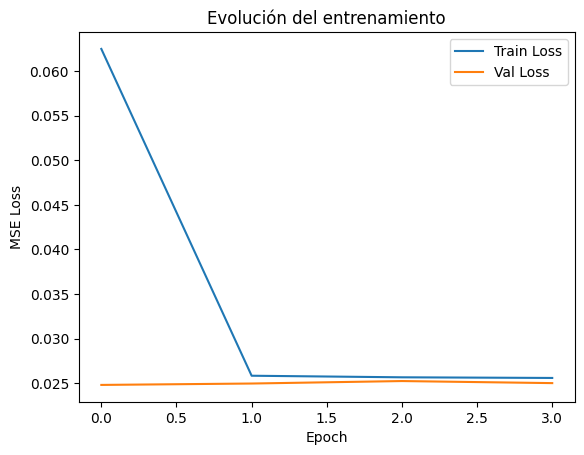

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Evolución del entrenamiento')
plt.show()


In [ ]:
import json

model.save("modelSave/model_9.keras")

with open('modelSave/history_9.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
import numpy as np
import pandas as pd
from itertools import product
from tqdm import tqdm  # opcional, solo para barra de progreso

# Número total de estaciones
num_stations = len(le_station.classes_)
print(f"Número total de estaciones: {num_stations}")

# Generar todas las combinaciones (inicio, fin)
pairs = list(product(range(num_stations), repeat=2))
print(f"Total de combinaciones: {len(pairs):,}")

# Separar índices de inicio y fin
start_indices = np.array([p[0] for p in pairs], dtype=np.int32)
end_indices = np.array([p[1] for p in pairs], dtype=np.int32)

# Crear un contexto base (ejemplo: condiciones neutras)
context_vec = np.zeros((1, X_context.shape[1]))  # todas las features a 0
context_matrix = np.repeat(context_vec, len(pairs), axis=0)

# --- Predicción ---
print("Realizando predicciones...")

batch_size = 4096  # ajusta según tu GPU/CPU
y_pred_log = model.predict(
    {
        'start_station': start_indices,
        'end_station': end_indices,
        'context': context_matrix
    },
    batch_size=batch_size,
    verbose=1
)

# Convertir de log a valores reales
y_pred = np.expm1(y_pred_log).flatten()

# Crear DataFrame con resultados
df_pred = pd.DataFrame({
    'start_station_idx': start_indices,
    'end_station_idx': end_indices,
    'predicted_trips': y_pred
})

# Decodificar nombres si tienes el LabelEncoder
df_pred['start_station'] = le_station.inverse_transform(df_pred['start_station_idx'])
df_pred['end_station'] = le_station.inverse_transform(df_pred['end_station_idx'])

# Ordenar por número de viajes estimado
df_pred_sorted = df_pred.sort_values('predicted_trips', ascending=False)

# Mostrar top 20
print(df_pred_sorted.head(10))

# (Opcional) Guardar en CSV
df_pred_sorted.to_csv("predicted_trips_all_pairs.csv", index=False)
print("Resultados guardados en 'predicted_trips_all_pairs.csv'")


Número total de estaciones: 1695
Total de combinaciones: 2,873,025
Realizando predicciones...
702/702 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step
         start_station_idx  end_station_idx  predicted_trips start_station  \
530277                 312             1437        25.530836         13160   
2647332               1561             1437        24.741404  TA1306000016   
2650722               1563             1437        24.732538  TA1306000026   
2691402               1587             1437        24.500870  TA1307000121   
2701572               1593             1437        24.482168  TA1307000130   
2342232               1381             1437        24.103085          E008   
598077                 352             1437        23.884945         13277   
2601567               1534             1437        23.815441  TA1305000010   
1128612                665             1437        23.538422         23139   
442137                 260             1437        23.298050         13022   

     